# Sales Forecasting using ARIMA

## Internship Project

### Objective

Predict future sales using historical sales data with the ARIMA Time Series Forecasting model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from math import sqrt

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\manik\OneDrive\Desktop\Sales_Forecasting\Superstore.csv", encoding="latin1")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [9]:
df = df.sort_values("Order Date")

In [10]:
sales = df.groupby("Order Date")["Sales"].sum()

In [11]:
sales.head()

Order Date
2014-01-03      16.448
2014-01-04     288.060
2014-01-05      19.536
2014-01-06    4407.100
2014-01-07      87.158
Name: Sales, dtype: float64

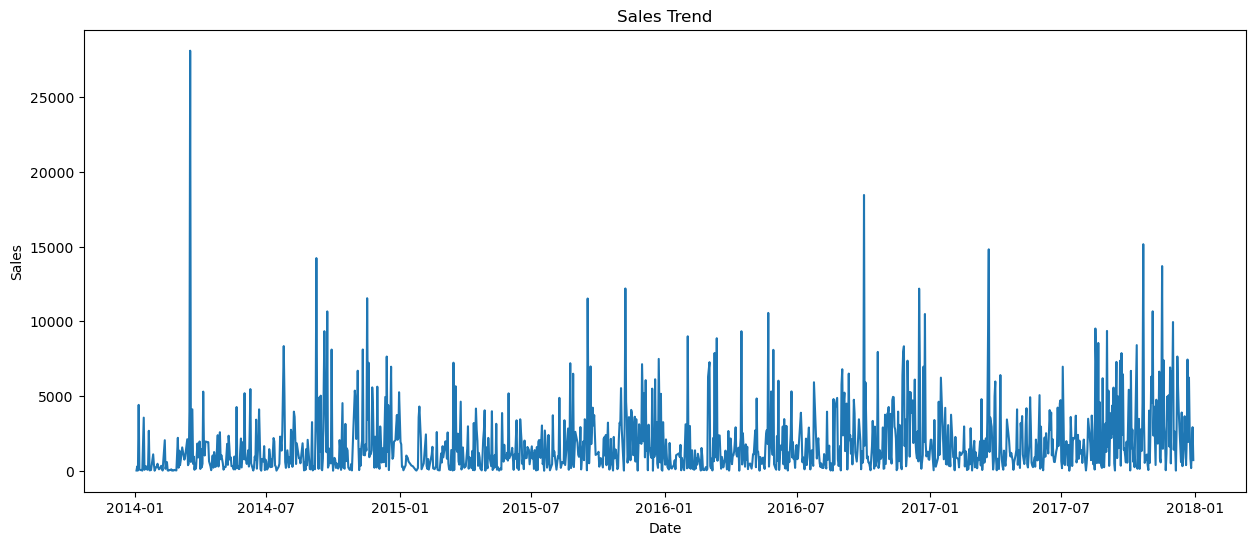

In [12]:
plt.figure(figsize=(15,6))

plt.plot(sales)

plt.title("Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

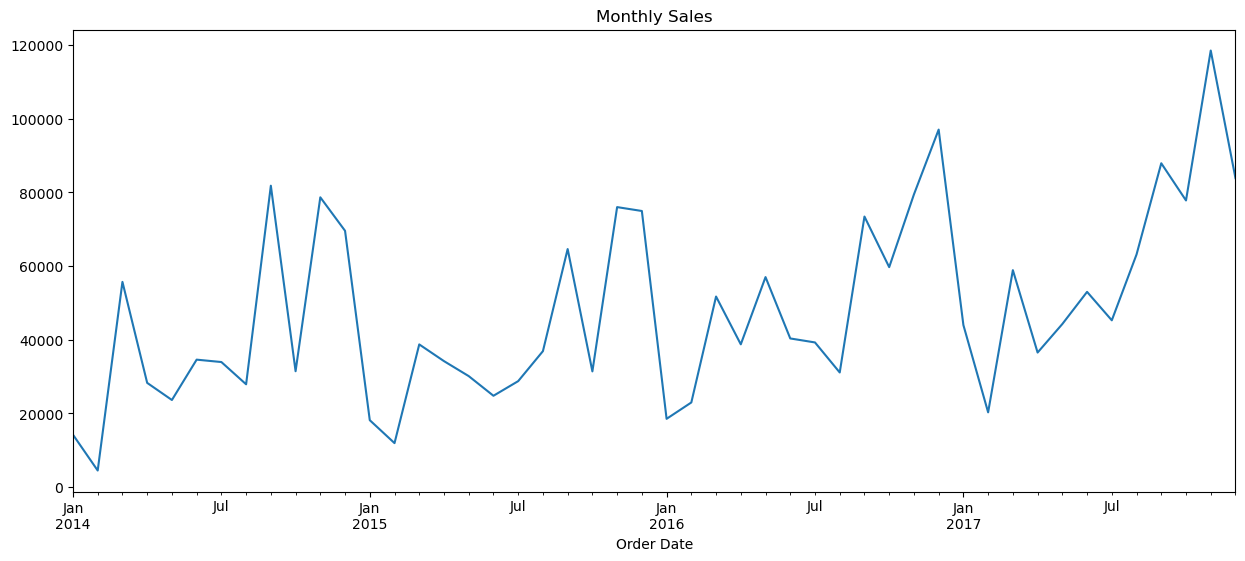

In [13]:
monthly_sales = sales.resample("M").sum()

monthly_sales.plot(figsize=(15,6))

plt.title("Monthly Sales")

plt.show()

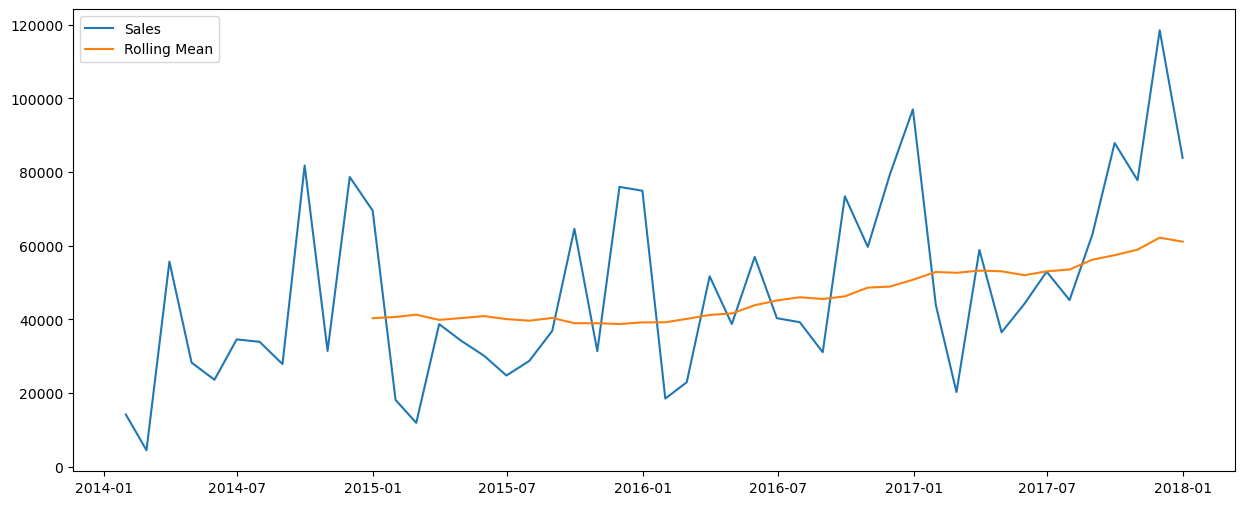

In [14]:
rolling = monthly_sales.rolling(12).mean()

plt.figure(figsize=(15,6))

plt.plot(monthly_sales,label="Sales")

plt.plot(rolling,label="Rolling Mean")

plt.legend()

plt.show()

In [15]:
train = monthly_sales[:-12]

test = monthly_sales[-12:]

In [16]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

In [17]:
forecast = model_fit.forecast(steps=12)

In [18]:
mae = mean_absolute_error(test, forecast)

rmse = sqrt(mean_squared_error(test, forecast))

print("MAE :",mae)

print("RMSE :",rmse)

MAE : 23961.65766161951
RMSE : 27328.054983542654


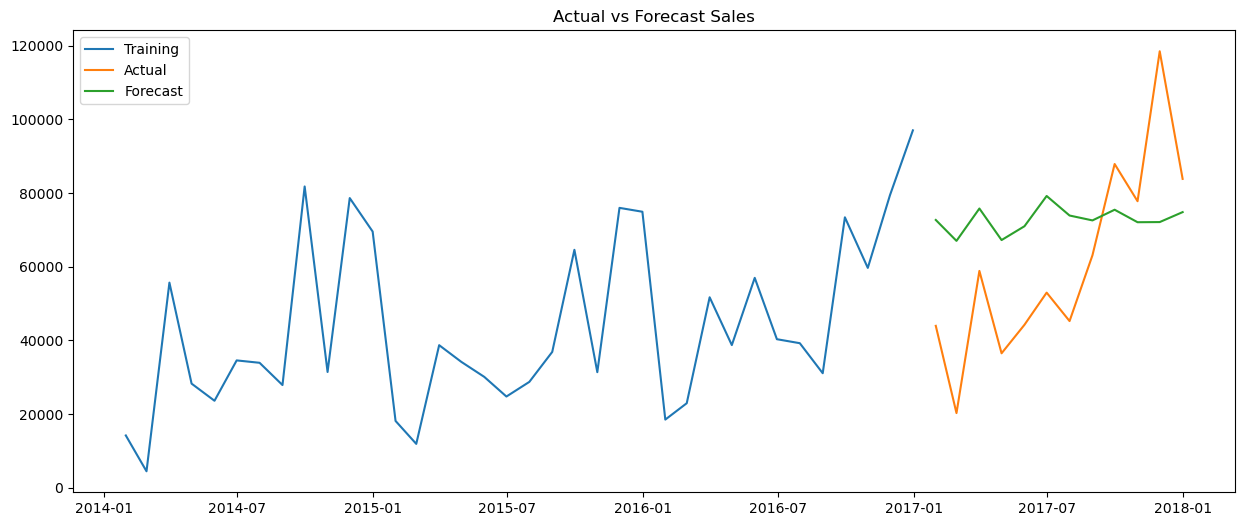

In [19]:
plt.figure(figsize=(15,6))

plt.plot(train.index,train,label="Training")

plt.plot(test.index,test,label="Actual")

plt.plot(test.index,forecast,label="Forecast")

plt.legend()

plt.title("Actual vs Forecast Sales")

plt.show()

In [20]:
future = model_fit.forecast(steps=6)

future

2017-01-31    72689.894592
2017-02-28    67019.882226
2017-03-31    75792.183906
2017-04-30    67239.060145
2017-05-31    70992.149429
2017-06-30    79196.516193
Freq: ME, Name: predicted_mean, dtype: float64

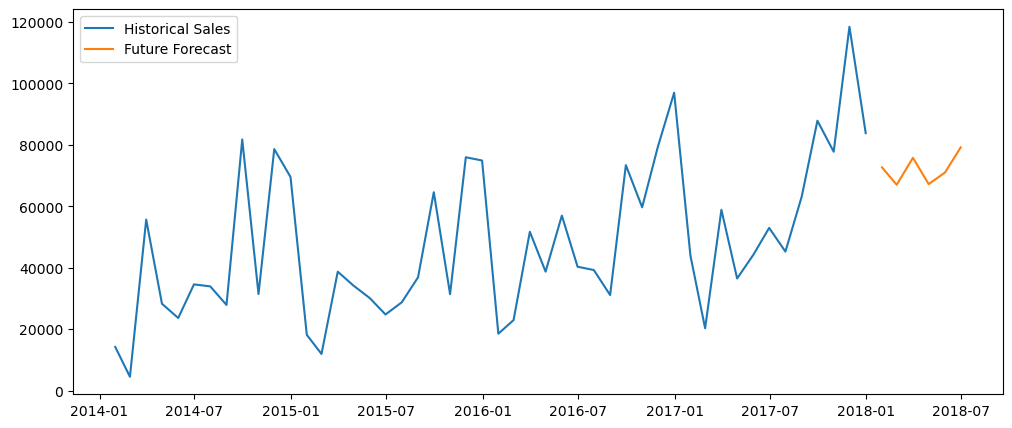

In [21]:
future_dates = pd.date_range(
    monthly_sales.index[-1],
    periods=7,
    freq="M"
)[1:]

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index,
         monthly_sales,
         label="Historical Sales")

plt.plot(future_dates,
         future,
         label="Future Forecast")

plt.legend()

plt.show()

# Conclusion

• Cleaned and prepared historical sales data.

• Performed time-series analysis.

• Built an ARIMA forecasting model.

• Forecasted future sales.

• Compared actual and predicted sales.

• Evaluated performance using MAE and RMSE.